In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series as fpppy_plot_series

import matplotlib.figure
matplotlib.figure.Figure.show = lambda self, *a, **k: None

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf

In [3]:
import sys
from pathlib import Path

In [4]:
cwd = Path.cwd()
project_root = cwd.parent
project_root

PosixPath('/Users/ak007/Projects/TS')

In [5]:
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

Done!


## Q1

1. Explore the following four time series: Bricks from aus_production, Lynx from pelt, GOOG_Close from gafa_stock, Demand from vic_elec.

- Use .info() to find out about the data in each series.
- What is the time interval of each series?
- Use plot_series() to produce a time plot of each series.
- For the last plot, modify the axis labels and title.

In [6]:
aus_prod = pd.read_csv(
    project_root / "data" / "aus_production.csv",
    parse_dates=["ds"]
)

In [10]:
aus_prod_bricks = aus_prod[["ds", "Bricks"]]
aus_prod_bricks.head()

,ds,Bricks
0,1956-01-01,189.0
1,1956-04-01,204.0
2,1956-07-01,208.0
3,1956-10-01,197.0
4,1957-01-01,187.0


In [11]:
aus_prod_bricks.info()

<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      218 non-null    datetime64[us]
 1   Bricks  198 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 3.5 KB


In [16]:
aus_prod_bricks.loc[aus_prod_bricks["Bricks"].isna()]

,ds,Bricks
198,2005-07-01,NaN
199,2005-10-01,NaN
200,2006-01-01,NaN
201,2006-04-01,NaN
202,2006-07-01,NaN
203,2006-10-01,NaN
204,2007-01-01,NaN
205,2007-04-01,NaN
206,2007-07-01,NaN
207,2007-10-01,NaN


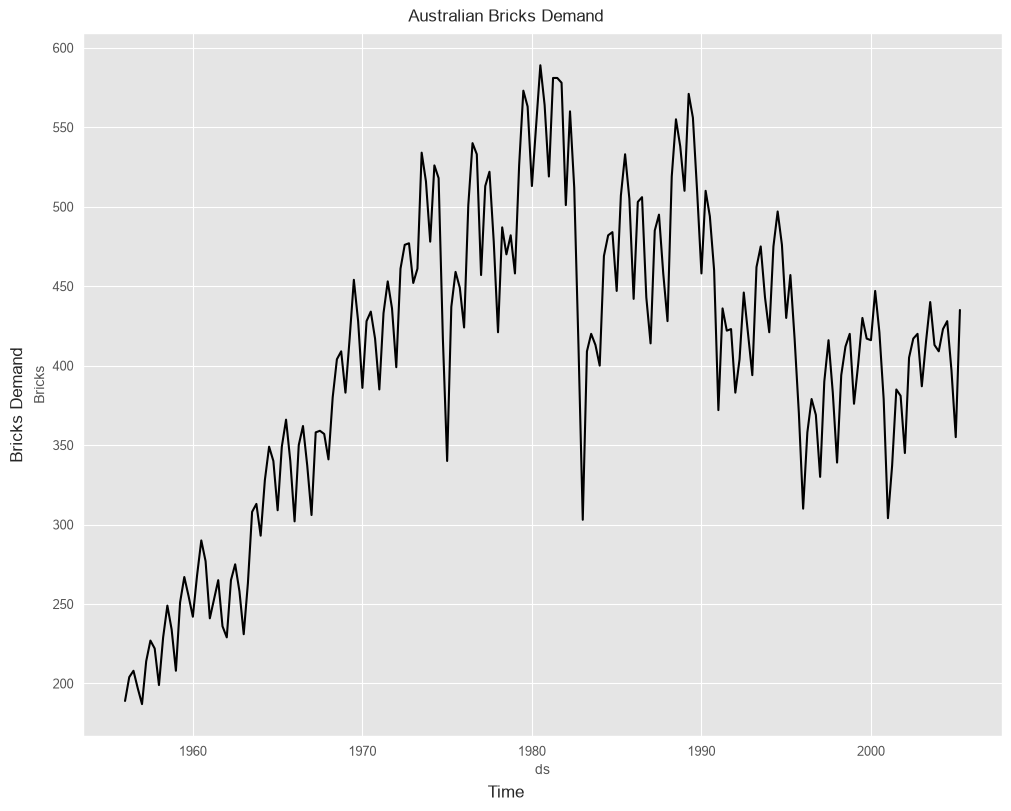

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.lineplot(
    data=aus_prod_bricks,
    x="ds",
    y="Bricks",
    ax=ax
)

fig.suptitle("Australian Bricks Demand")
fig.supxlabel("Time")
fig.supylabel("Bricks Demand")
fig.show()

In [21]:
g_stock = pd.read_csv(
    project_root / "data" / "gafa_stock.csv",
    parse_dates=["ds"]
)

In [22]:
g_stock

,unique_id,ds,y
0,AAPL_Open,2014-01-02,7.938e+01
1,AAPL_Open,2014-01-03,7.898e+01
2,AAPL_Open,2014-01-06,7.678e+01
3,AAPL_Open,2014-01-07,7.776e+01
4,AAPL_Open,2014-01-08,7.697e+01
...,...,...,...
30187,GOOG_Volume,2018-12-24,1.590e+06
30188,GOOG_Volume,2018-12-26,2.373e+06
30189,GOOG_Volume,2018-12-27,2.110e+06
30190,GOOG_Volume,2018-12-28,1.415e+06


In [25]:
g_stock['ds'].iloc[1] - g_stock['ds'].iloc[0]

Timedelta('1 days 00:00:00')

In [23]:
g_stock['unique_id'].unique()

<ArrowStringArray>
[     'AAPL_Open',      'AMZN_Open',        'FB_Open',      'GOOG_Open',
      'AAPL_High',      'AMZN_High',        'FB_High',      'GOOG_High',
       'AAPL_Low',       'AMZN_Low',         'FB_Low',       'GOOG_Low',
     'AAPL_Close',     'AMZN_Close',       'FB_Close',     'GOOG_Close',
 'AAPL_Adj_Close', 'AMZN_Adj_Close',   'FB_Adj_Close', 'GOOG_Adj_Close',
    'AAPL_Volume',    'AMZN_Volume',      'FB_Volume',    'GOOG_Volume']
Length: 24, dtype: str

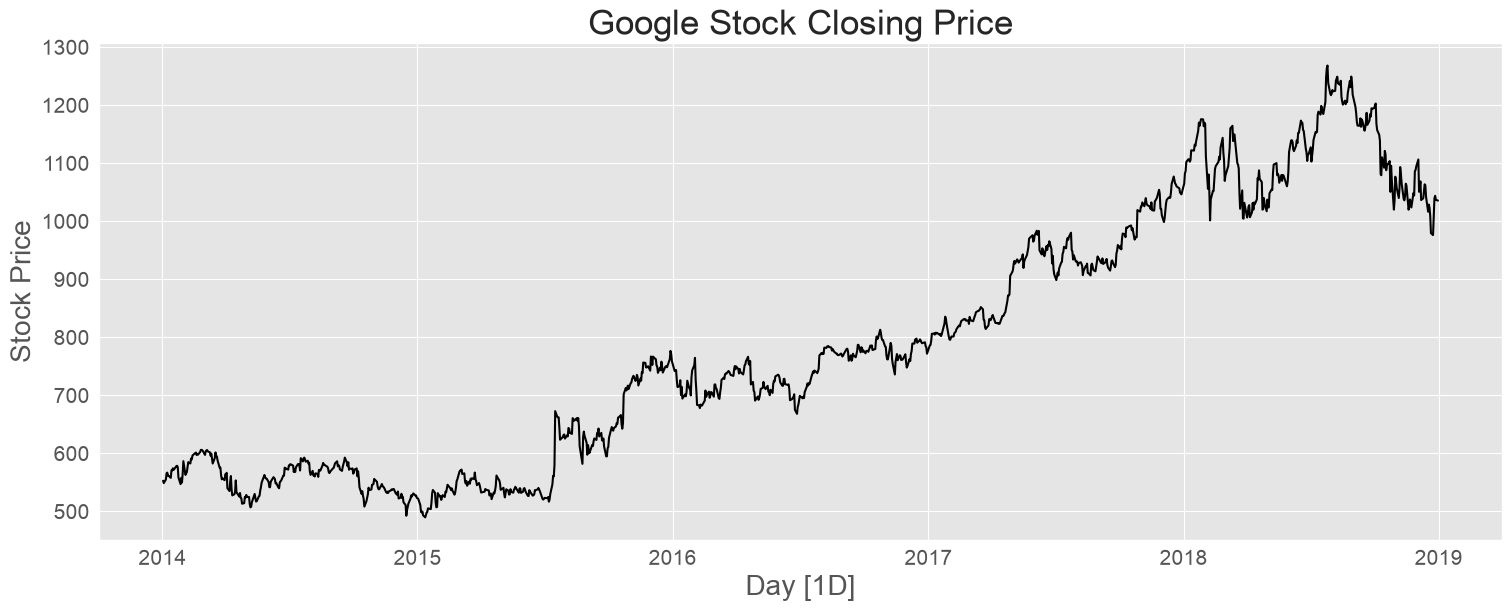

In [27]:
fpppy_plot_series(
    df=g_stock, ids=['GOOG_Close'], time_col="ds", target_col="y",
    xlabel='Day [1D]', ylabel="Stock Price",
    title='Google Stock Closing Price'
)

In [28]:
v_elec = pd.read_csv(
    project_root / "data" / "vic_elec.csv",
    parse_dates=['ds']
)

In [30]:
v_elec.head()

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825,True
1,2012-01-01 00:30:00,Demand,4263.366,True
2,2012-01-01 01:00:00,Demand,4048.966,True
3,2012-01-01 01:30:00,Demand,3877.563,True
4,2012-01-01 02:00:00,Demand,4036.230,True


In [31]:
v_elec['ds'].iloc[1] - v_elec['ds'].iloc[0]

Timedelta('0 days 00:30:00')

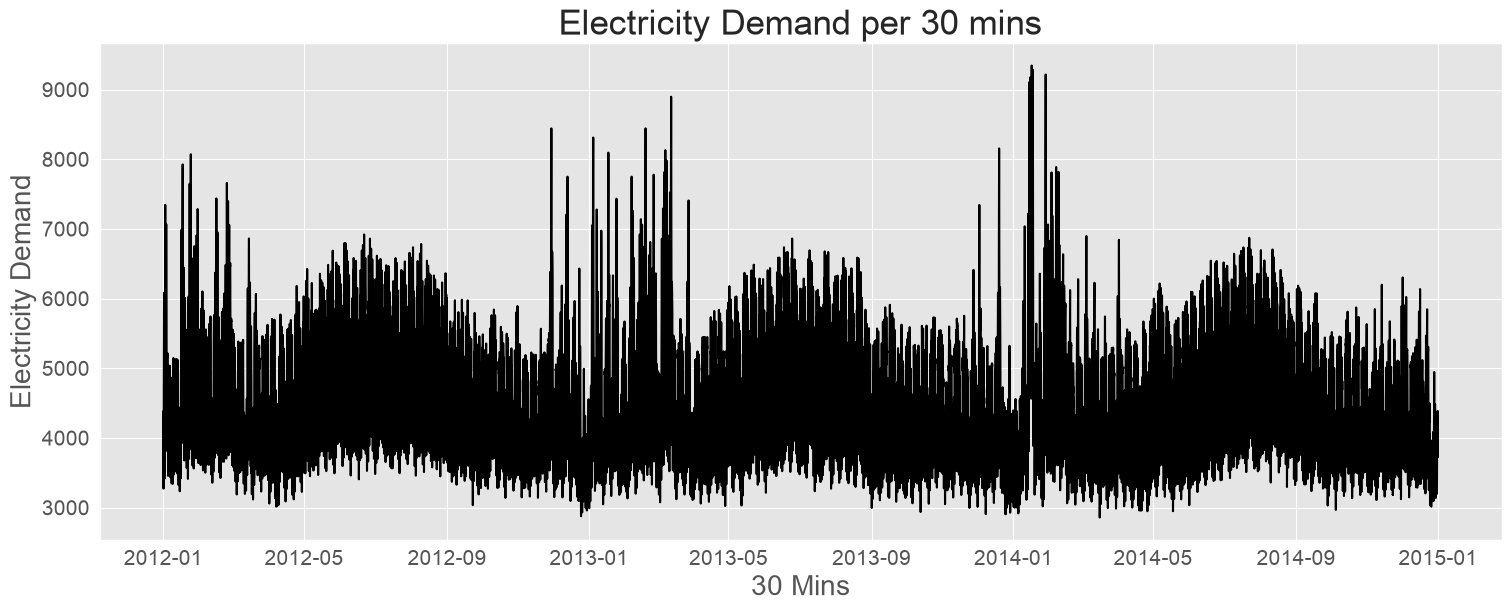

In [32]:
fpppy_plot_series(
    df=v_elec, ids=['Demand'], time_col="ds", target_col="y",
    xlabel='30 Mins', ylabel="Electricity Demand",
    title='Electricity Demand per 30 mins'
)

2. Use .loc[] or query() to find what days corresponded to the peak closing price for each of the four stocks in gafa_stock.

In [ ]:
g_stock.loc[g_stock['unique_id'].isin(["AMZN_Close", "AAPL_Close", "FB_Close", "GOOG_Close"])]

,unique_id,ds,y
15096,AAPL_Close,2014-01-02,79.019
15097,AAPL_Close,2014-01-03,77.283
15098,AAPL_Close,2014-01-06,77.704
15099,AAPL_Close,2014-01-07,77.149
15100,AAPL_Close,2014-01-08,77.637
...,...,...,...
20123,GOOG_Close,2018-12-24,976.220
20124,GOOG_Close,2018-12-26,1039.460
20125,GOOG_Close,2018-12-27,1043.880
20126,GOOG_Close,2018-12-28,1037.080


In [36]:
max_stock_price = g_stock.groupby(by=["unique_id"], as_index=False)["y"].max()

In [37]:
max_stock_price.loc[max_stock_price["unique_id"].isin(["AMZN_Close", "AAPL_Close", "FB_Close", "GOOG_Close"])]

,unique_id,y
1,AAPL_Close,232.07
7,AMZN_Close,2039.51
13,FB_Close,217.50
19,GOOG_Close,1268.33


In [38]:
idx = g_stock.groupby("unique_id")["y"].idxmax()

In [39]:
g_stock.loc[idx]

,unique_id,ds,y
21325,AAPL_Adj_Close,2018-10-03,2.303e+02
16293,AAPL_Close,2018-10-03,2.321e+02
6229,AAPL_High,2018-10-03,2.335e+02
11261,AAPL_Low,2018-10-03,2.298e+02
1198,AAPL_Open,2018-10-04,2.308e+02
25177,AAPL_Volume,2014-01-28,2.664e+08
22562,AMZN_Adj_Close,2018-09-04,2.040e+03
17530,AMZN_Close,2018-09-04,2.040e+03
7466,AMZN_High,2018-09-04,2.050e+03
12498,AMZN_Low,2018-09-04,2.013e+03


In [41]:
max_closing_stock_idx = (
    g_stock
    .groupby(by=['unique_id'])["y"]
    .idxmax()
)

max_closing_stock_prices = (
    g_stock
    .loc[max_closing_stock_idx]
    .query("unique_id in ['AMZN_Close', 'AAPL_Close', 'FB_Close', 'GOOG_Close']")
)

max_closing_stock_prices

,unique_id,ds,y
16293,AAPL_Close,2018-10-03,232.07
17530,AMZN_Close,2018-09-04,2039.51
18760,FB_Close,2018-07-25,217.50
20019,GOOG_Close,2018-07-26,1268.33


3. Download the file tute1.csv from the book website, open it in Excel (or some other spreadsheet application), and review its contents. You should find four columns of information. Columns B through D each contain a quarterly series, labelled Sales, AdBudget and GDP. Sales contains the quarterly sales for a small company over the period 1981–2005. AdBudget is the advertising budget and GDP is the gross domestic product. All series have been adjusted for inflation.

You can read the data into Python with the following script:

```
tute1 = pd.read_csv("tute1.csv", parse_dates=["ds"])
tute1.head()
```

Construct time series plots of each of the three series

```
plot_series(tute1)
```

In [8]:
tute_df = pd.read_csv(
    project_root / "data" / "tute1.csv",
    parse_dates=['Quarter']
)

In [9]:
tute_df.head()

,Quarter,Sales,AdBudget,GDP
0,1981-03-01,1020.2,659.2,251.8
1,1981-06-01,889.2,589.0,290.9
2,1981-09-01,795.0,512.5,290.8
3,1981-12-01,1003.9,614.1,292.4
4,1982-03-01,1057.7,647.2,279.1


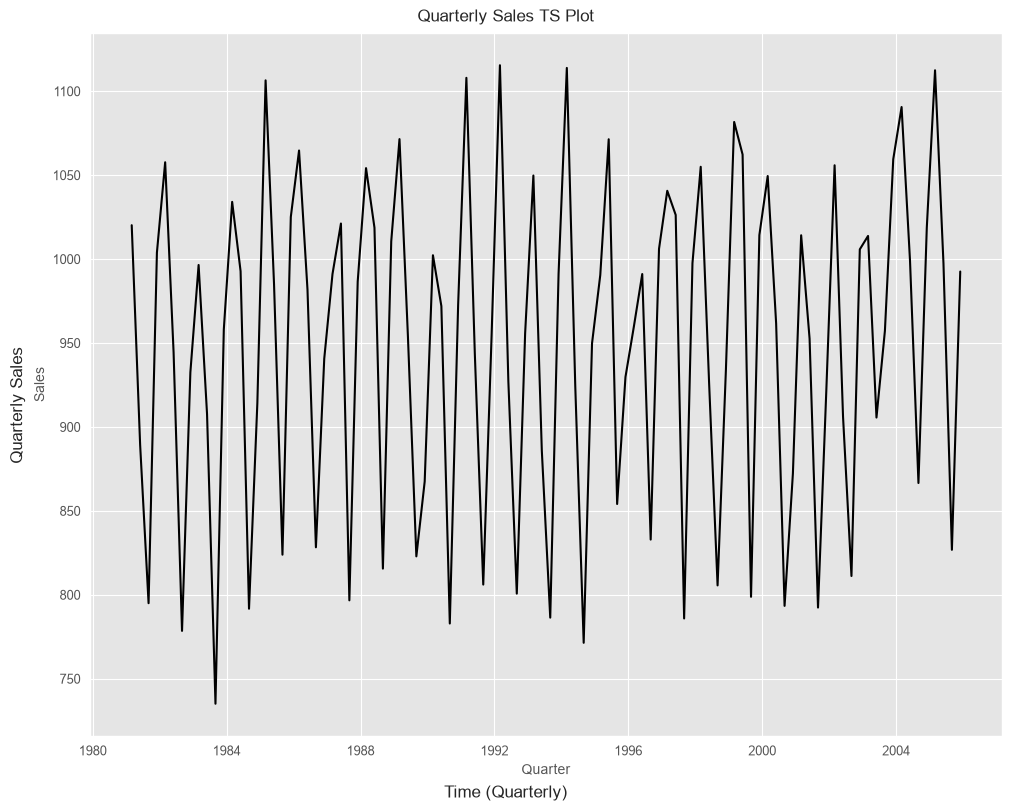

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.lineplot(
    data=tute_df,
    x="Quarter",
    y="Sales",
    ax=ax
)

fig.supxlabel("Time (Quarterly)")
fig.supylabel("Quarterly Sales")
fig.suptitle("Quarterly Sales TS Plot")
fig.show()

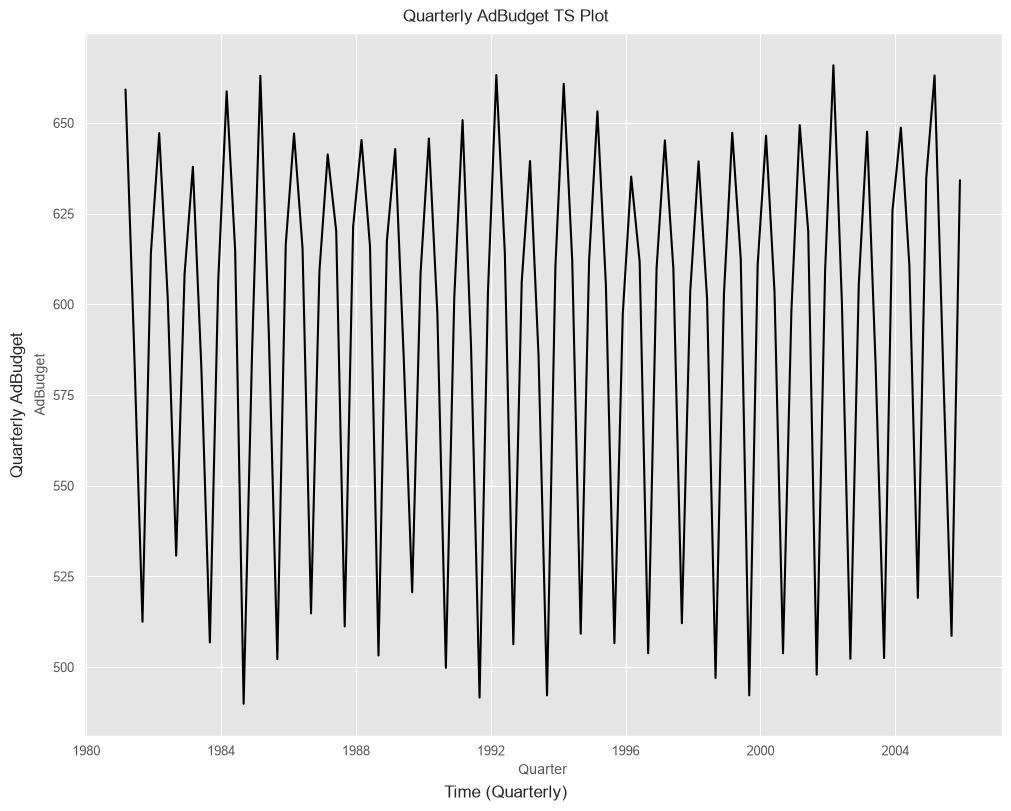

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.lineplot(
    data=tute_df,
    x="Quarter",
    y="AdBudget",
    ax=ax
)

fig.supxlabel("Time (Quarterly)")
fig.supylabel("Quarterly AdBudget")
fig.suptitle("Quarterly AdBudget TS Plot")
fig.show()

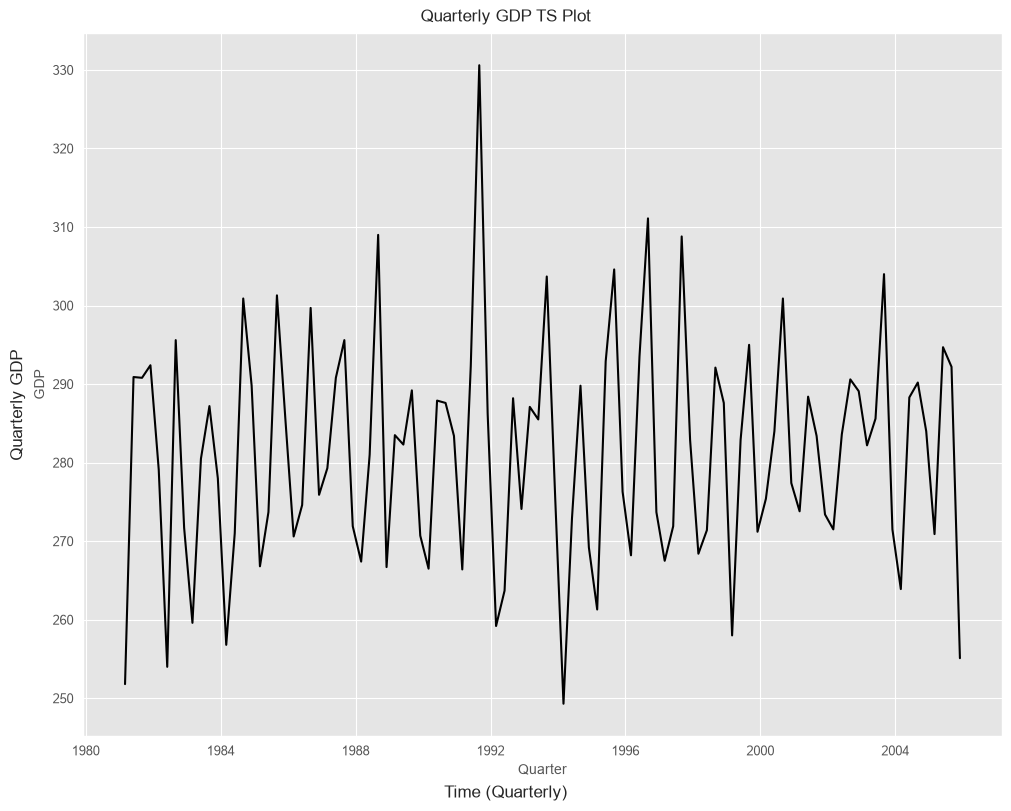

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.lineplot(
    data=tute_df,
    x="Quarter",
    y="GDP",
    ax=ax
)

fig.supxlabel("Time (Quarterly)")
fig.supylabel("Quarterly GDP")
fig.suptitle("Quarterly GDP TS Plot")
fig.show()

In [28]:
# plotting all three in one plot
features = ["Sales", "AdBudget", "GDP"]

cmap = plt.get_cmap("tab10")

colors = {
    feature: cmap(i / (len(features) - 1))
    for i, feature in enumerate(features)
}

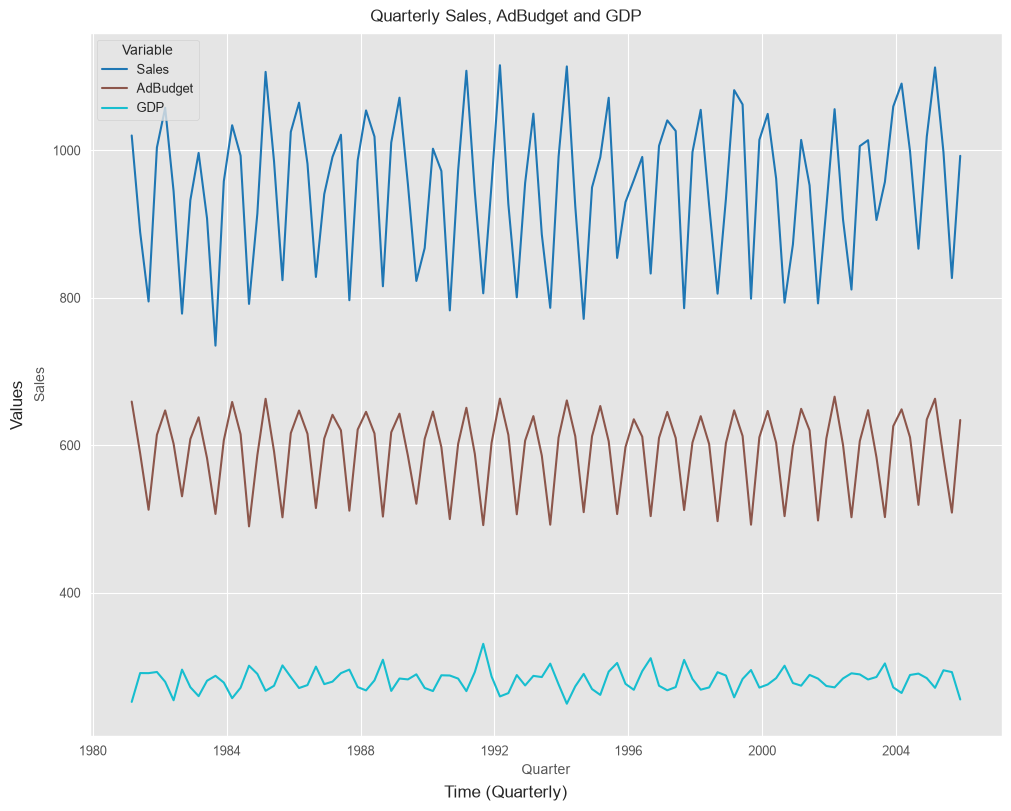

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

for feature in features:
    sns.lineplot(
        data=tute_df,
        x="Quarter",
        y=feature,
        ax=ax,
        color=colors[feature],
        label=feature,
    )
    
fig.suptitle("Quarterly Sales, AdBudget and GDP")
fig.supxlabel("Time (Quarterly)")
fig.supylabel("Values")

ax.legend(title="Variable")

fig.show()

4. The us_total.csv contains data on the demand for natural gas in the US. 

Download us_total.csv from the book website read in the csv file using pd.read_csv().
Create a dataframe from us_total with year as the index.
Plot the annual natural gas consumption by state for the New England area (comprising the states of Maine, Vermont, New Hampshire, Massachusetts, Connecticut and Rhode Island).

In [6]:
us_totals = pd.read_csv(
    project_root / "data" / "us_total.csv",
    parse_dates=['ds'],
)

us_totals.head()

,ds,unique_id,y
0,1997-01-01,Alabama,324158
1,1998-01-01,Alabama,329134
2,1999-01-01,Alabama,337270
3,2000-01-01,Alabama,353614
4,2001-01-01,Alabama,332693


In [7]:
us_totals['year'] = us_totals['ds'].dt.year

In [8]:
us_totals.columns

Index(['ds', 'unique_id', 'y', 'year'], dtype='str')

In [9]:
us_totals = us_totals.set_index("year")

In [10]:
us_totals

,ds,unique_id,y
year,,,
1997,1997-01-01,Alabama,324158
1998,1998-01-01,Alabama,329134
1999,1999-01-01,Alabama,337270
2000,2000-01-01,Alabama,353614
2001,2001-01-01,Alabama,332693
...,...,...,...
2015,2015-01-01,Wyoming,119265
2016,2016-01-01,Wyoming,123351
2017,2017-01-01,Wyoming,149405


In [11]:
states = ['Maine', 'Vermont', 'New Hampshire', 'Massachusetts', 'Connecticut', 'Rhode Island']

new_eng = us_totals.loc[us_totals['unique_id'].isin(states)]

In [12]:
new_eng

,ds,unique_id,y
year,,,
1997,1997-01-01,Connecticut,144708
1998,1998-01-01,Connecticut,131497
1999,1999-01-01,Connecticut,152237
2000,2000-01-01,Connecticut,159712
2001,2001-01-01,Connecticut,146278
...,...,...,...
2015,2015-01-01,Vermont,11950
2016,2016-01-01,Vermont,12094
2017,2017-01-01,Vermont,11926


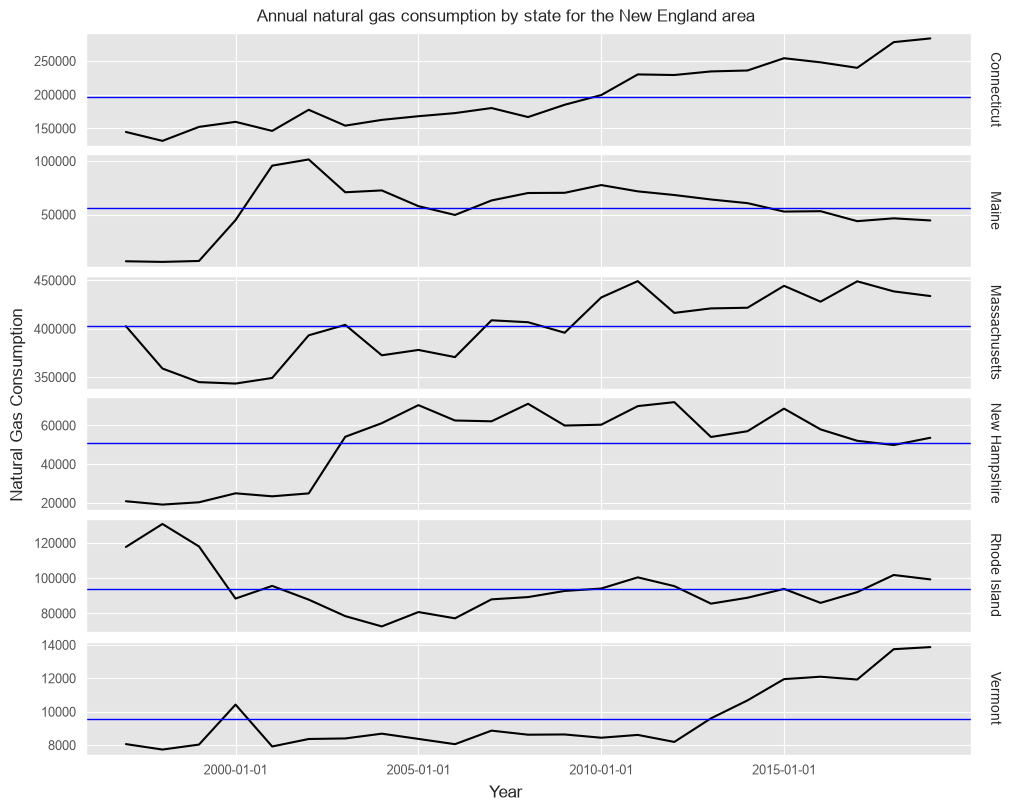

In [19]:
fig, axes = plt.subplots(len(states), 1, figsize=(10, 8), sharex=True, sharey="row")

for ax, (state, state_df) in zip(axes, new_eng.groupby(by="unique_id")):
    sns.lineplot(
        data=state_df,
        x="ds",
        y='y',
        ax=ax,
    )
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.axhline(state_df['y'].mean(), color='b', linewidth=1)
    xticks = state_df['ds'].loc[lambda x: x.dt.year % 5 == 0]
    ax.set(xticks=xticks)
    ax.text(
        1.02,
        0.5,
        state,
        va="center",
        ha="left",
        rotation=270,
        size="medium",
        transform=ax.transAxes,
    )
    
fig.suptitle("Annual natural gas consumption by state for the New England area")
fig.supxlabel("Year")
fig.supylabel("Natural Gas Consumption")
fig.show()

5. Download tourism.xlsx from the book website and read in it using pd.read_excel().
Create a dataframe using tourism.xlsx.
Find what combination of Region and Purpose had the maximum number of overnight trips on average.
Create a new dataframe which combines the Purposes and Regions, and just has total trips by State.

In [20]:
tour = pd.read_csv(
    project_root / "data" / "tourism.csv",
    parse_dates=['ds']
)

tour.head()

,ds,Region,State,Purpose,y
0,1998-01-01,Adelaide,South Australia,Business,135.078
1,1998-04-01,Adelaide,South Australia,Business,109.987
2,1998-07-01,Adelaide,South Australia,Business,166.035
3,1998-10-01,Adelaide,South Australia,Business,127.160
4,1999-01-01,Adelaide,South Australia,Business,137.449


In [31]:
region_purpose_comb_avg = (
    tour
    .groupby(by=['Region', 'Purpose'], as_index=False)['y']
    .mean()
)

region_purpose_comb_avg

,Region,Purpose,y
0,Adelaide,Business,155.528
1,Adelaide,Holiday,156.543
2,Adelaide,Other,56.563
3,Adelaide,Visiting,205.194
4,Adelaide Hills,Business,2.664
...,...,...,...
299,Wimmera,Visiting,14.880
300,Yorke Peninsula,Business,6.892
301,Yorke Peninsula,Holiday,80.088
302,Yorke Peninsula,Other,1.886


In [ ]:
region_purpose_comb_avg.loc[region_purpose_comb_avg['y'].idxmax()]

Region       Sydney
Purpose    Visiting
y            747.27
Name: 271, dtype: object

In [34]:
state_total = tour.groupby(by='State', as_index=False)['y'].sum()
state_total

,State,y
0,ACT,41006.585
1,New South Wales,557367.430
2,Northern Territory,28613.683
3,Queensland,386642.912
4,South Australia,118151.348
5,Tasmania,54137.095
6,Victoria,390462.911
7,Western Australia,147819.653


6. The aus_arrivals data set comprises quarterly international arrivals to Australia from Japan, New Zealand, UK and the US.

- Use plot_series() to visualise the data.
- Use seaborn or matplotlib to create seasonal and subseries plots to compare the differences between the arrivals from these four countries and identify any unusual observations.

In [15]:
aus_arr = (
    pd.read_csv(
        project_root / 'data' / 'aus_arrivals.csv',
        parse_dates=['Quarter']
    )
    .rename(columns={"Quarter": "ds"})
    .assign(
        Quarter=lambda x: 'Q' + x['ds'].dt.quarter.astype(str)
    )
)
aus_arr

,ds,Origin,Arrivals,Quarter
0,1981-01-01,Japan,14763,Q1
1,1981-04-01,Japan,9321,Q2
2,1981-07-01,Japan,10166,Q3
3,1981-10-01,Japan,19509,Q4
4,1982-01-01,Japan,17117,Q1
...,...,...,...,...
503,2011-07-01,US,101925,Q3
504,2011-10-01,US,127150,Q4
505,2012-01-01,US,129520,Q1
506,2012-04-01,US,105700,Q2


In [16]:
aus_arr.info()

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   ds        508 non-null    datetime64[us]
 1   Origin    508 non-null    str           
 2   Arrivals  508 non-null    int64         
 3   Quarter   508 non-null    str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 18.4 KB


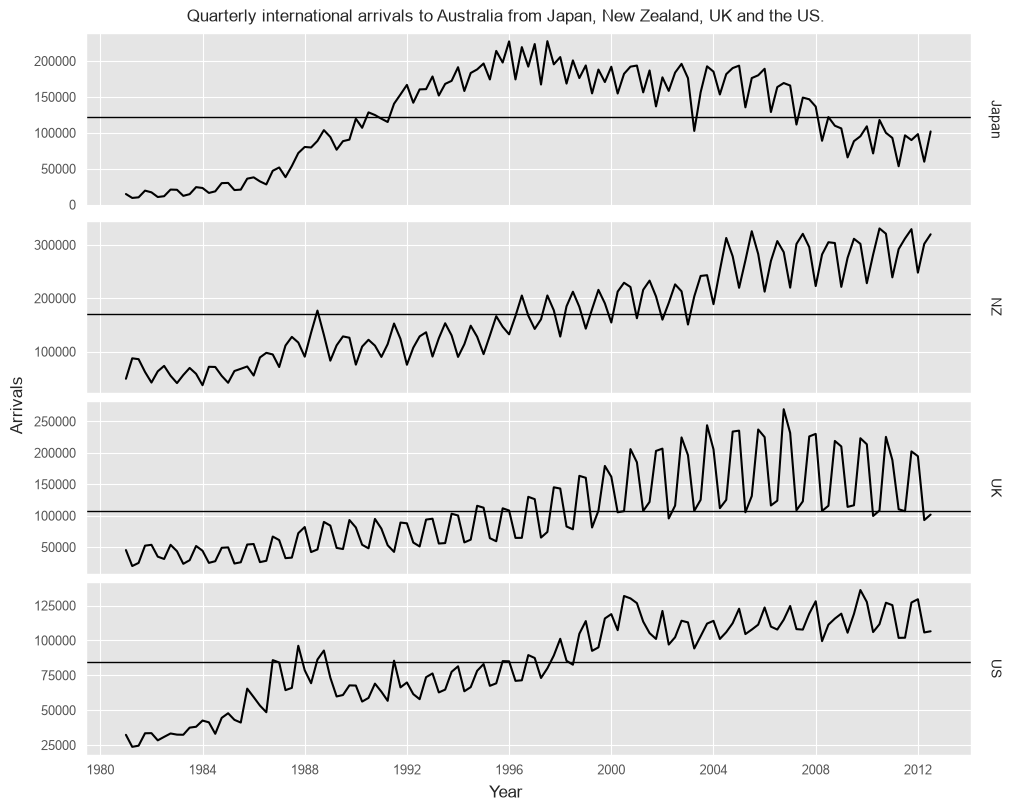

In [17]:
fig, axes = plt.subplots(len(aus_arr['Origin'].unique()), 1,
                         figsize=(10,8),
                         sharex=True,
)

for ax, (country, country_df) in zip(axes, aus_arr.groupby(by='Origin')):
    sns.lineplot(
        data=country_df,
        x="ds",
        y="Arrivals",
        ax=ax
    )
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.axhline(country_df['Arrivals'].mean(), linewidth = 1)
    
    ax.text(
        1.02,
        0.5,
        country,
        va="center",
        ha="left",
        rotation=270,
        size="medium",
        transform=ax.transAxes,
    )
    
fig.suptitle("Quarterly international arrivals to Australia from Japan, New Zealand, UK and the US.")
fig.supxlabel("Year")
fig.supylabel("Arrivals")
fig.show()

In [18]:
aus_arr['Year'] = aus_arr['ds'].dt.year

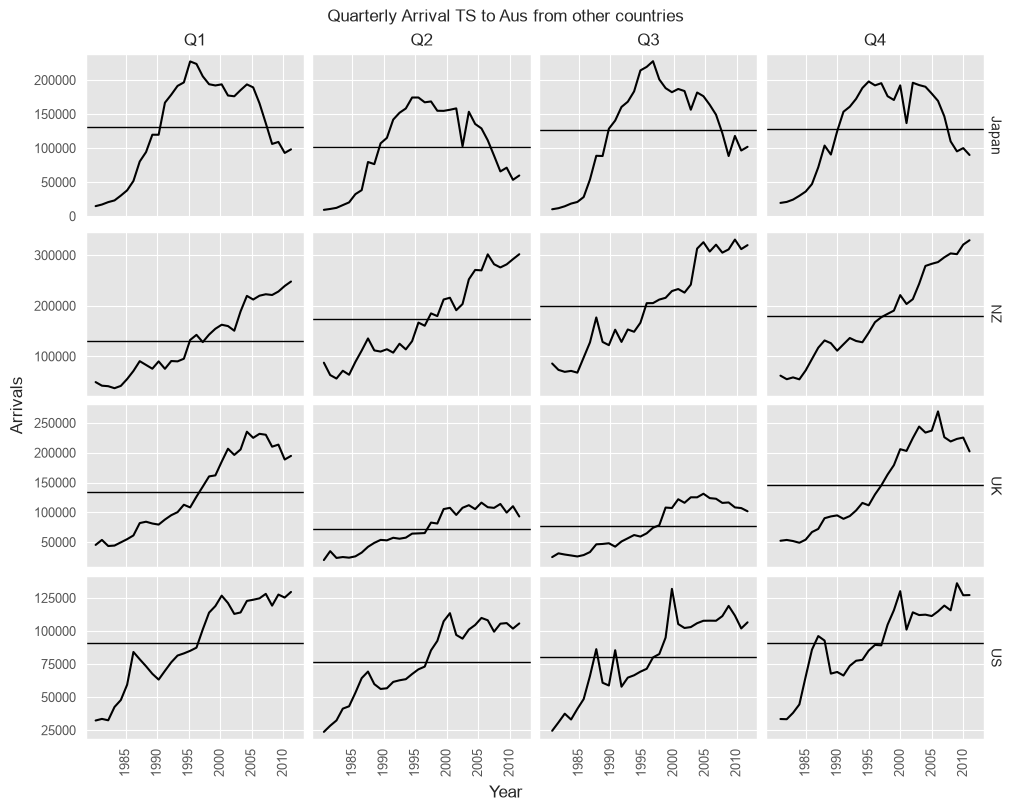

In [25]:
fig, axes = plt.subplots(4, 4,
                         figsize=(10, 8),
                         sharex=True,
                         sharey='row'
)

for ax, ((country, quarter), cq_df) in zip(axes.flat, aus_arr.groupby(by=['Origin', 'Quarter'])):
    ax.plot(cq_df['ds'], cq_df['Arrivals'], color='k')
    ax.axhline(cq_df['Arrivals'].mean(), linewidth=1)
    ax.tick_params(axis='x', rotation=90)
    xticks = cq_df.loc[
        cq_df["Year"] % 5 == 0,
        "ds"
    ]

    if ax in axes[0, :]:
        ax.set(
            title=quarter,
            xticks=xticks
        )
    if ax in axes[:, -1]:
        ax.text(
            1.02,
            0.5,
            country,
            va="center",
            ha="left",
            rotation=270,
            size="medium",
            transform=ax.transAxes
        )
        
fig.suptitle("Quarterly Arrival TS to Aus from other countries")
fig.supxlabel("Year")
fig.supylabel("Arrivals")
fig.show()